提取 HSV colour histogram
    1.读取同一张图片
    2.转 HSV
    3.计算 H、S、V 三个通道 histogram
    4.normalize histogram
    5.拼接三个通道
    6.打印 feature shape

# Colour Histogram Feature Extraction

It extracts colour histogram features from the iNaturalist images.

## Import Libraries and Project Settings

Load the required libraries and shared project configuration.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Find the project root
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src").exists() and (path / "data").exists()
)

# Allow imports from the project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

print("Project root:", PROJECT_ROOT)
print("Image size:", config.IMG_SIZE)

Project root: c:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group
Image size: (224, 224)


## Load a Sample Image

Read one training image and resize it to the shared input size.

Image path: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\data\raw\train_mini\07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii\f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
Label: 364
Species: Xylorhiza orcuttii
Image size: (224, 224)


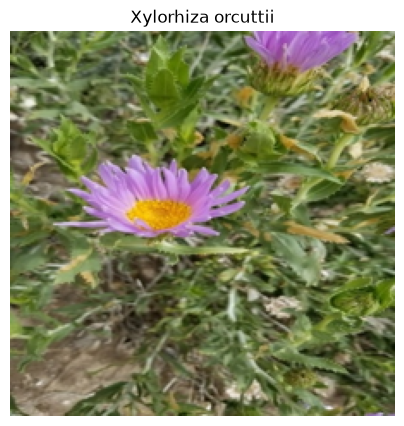

In [3]:
train_df = pd.read_csv(config.TRAIN_CSV)

sample = train_df.iloc[0]
image_path = config.DATA_RAW_ROOT / sample["file_path"]

with Image.open(image_path) as sample_image:
    image = sample_image.convert("RGB").resize(config.IMG_SIZE)

print("Image path:", image_path)
print("Label:", sample["label"])
print("Species:", sample["category_name"])
print("Image size:", image.size)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(sample["category_name"])
plt.show()

## Extract the Colour Histogram

Calculate a normalised histogram for the red, green, and blue channels.

In [4]:
image_array = np.asarray(image)

red_hist, _ = np.histogram(
    image_array[:, :, 0],
    bins=32,
    range=(0, 256)
)

green_hist, _ = np.histogram(
    image_array[:, :, 1],
    bins=32,
    range=(0, 256)
)

blue_hist, _ = np.histogram(
    image_array[:, :, 2],
    bins=32,
    range=(0, 256)
)

red_hist = red_hist / red_hist.sum()
green_hist = green_hist / green_hist.sum()
blue_hist = blue_hist / blue_hist.sum()

colour_feature = np.concatenate([
    red_hist,
    green_hist,
    blue_hist
]).astype(np.float32)

print("Feature type:", type(colour_feature))
print("Feature dtype:", colour_feature.dtype)
print("Feature shape:", colour_feature.shape)

Feature type: <class 'numpy.ndarray'>
Feature dtype: float32
Feature shape: (96,)


## Visualise the Colour Histograms

Display the normalised histograms for the red, green, and blue channels.

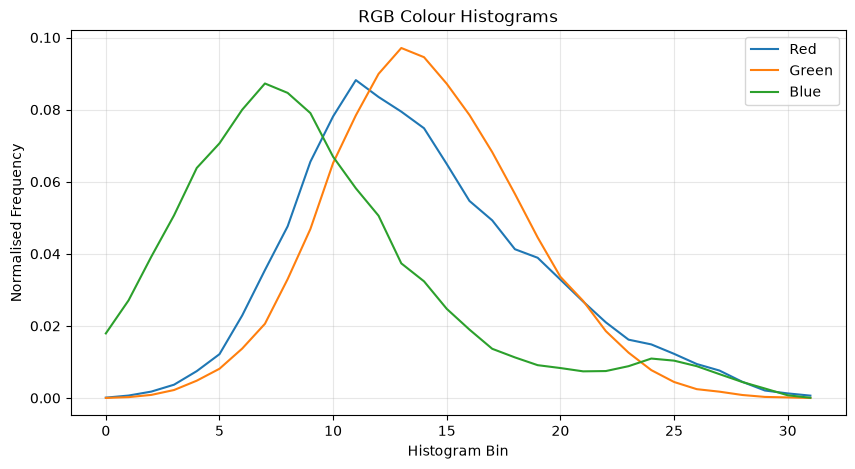

In [5]:
bin_positions = np.arange(32)

plt.figure(figsize=(10, 5))

plt.plot(bin_positions, red_hist, label="Red")
plt.plot(bin_positions, green_hist, label="Green")
plt.plot(bin_positions, blue_hist, label="Blue")

plt.xlabel("Histogram Bin")
plt.ylabel("Normalised Frequency")
plt.title("RGB Colour Histograms")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Create a Reusable Colour Feature Function

Define a function that extracts the same colour histogram feature from any PIL image.

In [6]:
def extract_colour_feature(image, bins=32):
    """Extract a normalised RGB colour histogram from a PIL image."""

    resized_image = image.convert("RGB").resize(config.IMG_SIZE)
    image_array = np.asarray(resized_image)

    channel_features = []

    for channel in range(3):
        histogram, _ = np.histogram(
            image_array[:, :, channel],
            bins=bins,
            range=(0, 256)
        )

        histogram = histogram.astype(np.float32)

        if histogram.sum() > 0:
            histogram /= histogram.sum()

        channel_features.append(histogram)

    feature = np.concatenate(channel_features)

    return feature.astype(np.float32)

## Test the Colour Feature Function

Check the feature type, data type, length, and normalisation.

In [7]:
test_feature = extract_colour_feature(image)

print("Feature type:", type(test_feature))
print("Feature dtype:", test_feature.dtype)
print("Feature shape:", test_feature.shape)
print("Feature length:", len(test_feature))

print("Red histogram sum:", test_feature[:32].sum())
print("Green histogram sum:", test_feature[32:64].sum())
print("Blue histogram sum:", test_feature[64:96].sum())

Feature type: <class 'numpy.ndarray'>
Feature dtype: float32
Feature shape: (96,)
Feature length: 96
Red histogram sum: 1.0
Green histogram sum: 1.0
Blue histogram sum: 1.0


## Test Images from Different Classes

Check that images from different species produce colour features with the same length.

In [8]:
# Select images from different classes
sample_rows = (
    train_df
    .drop_duplicates(subset="label")
    .head(5)
)

feature_lengths = []

for _, sample in sample_rows.iterrows():
    sample_path = config.DATA_RAW_ROOT / sample["file_path"]

    with Image.open(sample_path) as sample_image:
        sample_feature = extract_colour_feature(sample_image)

    feature_lengths.append(len(sample_feature))

    print(
        "Label:",
        sample["label"],
        "- Species:",
        sample["category_name"],
        "- Feature length:",
        len(sample_feature)
    )

print("All feature lengths:", feature_lengths)
print("Same length:", len(set(feature_lengths)) == 1)

Label: 364 - Species: Xylorhiza orcuttii - Feature length: 96
Label: 251 - Species: Sceloporus orcutti - Feature length: 96
Label: 449 - Species: Malvaviscus arboreus - Feature length: 96
Label: 404 - Species: Lysimachia clethroides - Feature length: 96
Label: 199 - Species: Pycnonotus leucotis - Feature length: 96
All feature lengths: [96, 96, 96, 96, 96]
Same length: True


## Summary

Each image is resized to 224 × 224 before colour feature extraction.

A normalised 32-bin histogram is calculated for each RGB channel. The three histograms are combined into a fixed-length feature vector of 96 values.

The feature vector uses the `float32` data type and has the same length for images from different classes. It can later be combined with the HOG feature.